# Portföljkonstruktion & Skev Avkastningsanalys i Nordiska Aktiemarknader

# 1. Research Questions

1. **Skevhet över investeringshorisonter:** Do pooled return distributions in Nordic
   equity markets display significant positive skewness across different investment
   horizons?

2. **Koncentration av värdeskapande:** How concentrated is long-term wealth creation
   across firms in the Nordic equity markets?

3. **Portföljkonstruktionens påverkan:** How do different portfolio construction
   methods — including portfolio size, weighting schemes, and random and informed
   selection strategies — affect portfolio return distributions in a market
   characterized by skewed and concentrated stock returns?

In [1]:
# importerar alla bibliotek som behövs
import pandas as pd
import numpy as np
import random
import seaborn as sns
from itertools import product
import matplotlib.pyplot as plt
from scipy import stats
import warnings
from functools import lru_cache
import matplotlib as mpl
warnings.filterwarnings("ignore", category=FutureWarning)



In [2]:
# Plottinställningar
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
new_style = mpl.rc_params_from_file('C:\\Source\\KvartilPython\\kvartil.mplstyle', use_default_template=False)
plt.rcParams.update(new_style)

# 2. Hjälpfunktioner

In [11]:
def get_kfs(rets, benchrets, periods_yr=12, monthly_vol=False):
    rets_m = rets
    benchrets_m = (
        (1 + benchrets)
        .cumprod()
        .resample("ME")
        .last()
        .pct_change()
        .dropna()
        .reindex(rets_m.index)
    )
    if len(rets) > len(rets_m)*12:
        yrs = (rets.index[-1] - rets.index[0]) / np.timedelta64(365, "D")
    else:
        yrs = len(rets_m) / 12
    dd = 1 - (1 + rets).cumprod() / (1 + rets).cumprod().expanding().max()
    yr = np.power((1 + rets).cumprod().iloc[-1], 1 / yrs) - 1
    if monthly_vol:
        yv = rets_m.std() * np.sqrt(12)
    else:
        yv = rets.std() * np.sqrt(periods_yr)
    max_dd = dd.max()
    mean_dd = dd.mean()
    ir = yr / yv
    beta = rets_m.corrwith(benchrets_m) * rets_m.std() / benchrets_m.std()
    downside_capture = (
        rets_m[benchrets_m < 0].mean() / benchrets_m[benchrets_m < 0].mean()
    )
    upside_capture = (
        rets_m[benchrets_m > 0].mean() / benchrets_m[benchrets_m > 0].mean()
    )
    share_up_month = (rets_m > 0).mean()
    avg_down_month = rets_m[rets_m < 0].mean()
    avg_up_month = rets_m[rets_m > 0].mean()
    rets_0 = rets.sub(rets.mean())
    upside_vol = rets_0[rets_0 > 0].std() * np.sqrt(periods_yr)
    downside_vol = rets_0[rets_0 < 0].std() * np.sqrt(periods_yr)
    betting_average = (rets_m.sub(benchrets_m, axis=0) >= 0.000001).mean()
    var95 = rets_m.quantile(0.05)
    var975 = rets_m.quantile(0.025)
    var99 = rets_m.quantile(0.01)
    cvar = rets_m[rets_m < var95].mean()
    skew = rets_m.skew()
    kurtosis = rets_m.kurtosis()
    sortino_ratio = yr / downside_vol
    calmar_ratio = yr / abs(max_dd)

    if type(yr) == pd.Series:
        return pd.concat(
            {
                "Return": yr,
                "Vol": yv,
                "Max DrawDown": max_dd,
                "Information Ratio": ir,
                "Beta": beta,
                "Downside Capture": downside_capture,
                "Upside capture": upside_capture,
                "Share up month": share_up_month,
                "Avg. down-month": avg_down_month,
                "Avg. up-month": avg_up_month,
                "Downside vol.": downside_vol,
                "Upside vol.": upside_vol,
                "Batting average": betting_average,
                "VaR 95%": var95,
                "VaR 99%": var99,
                "Conditional VaR (5%)": cvar,
                "Skew": skew,
                "Kurtosis": kurtosis,
                "Sortinokvot": sortino_ratio,
                "Calmarkvot": calmar_ratio,
            },
            axis=1,
        )
    else:
        return pd.Series(
            {
                "Return": yr,
                "Vol": yv,
                "Max DrawDown": max_dd,
                "Information Ratio": ir,
                "Beta": beta,
                "Downside Capture": downside_capture,
                "Upside capture": upside_capture,
                "Share up month": share_up_month,
                "Avg. down-month": avg_down_month,
                "Avg. up-month": avg_up_month,
                "Downside vol.": downside_vol,
                "Upside vol.": upside_vol,
                "Batting average": betting_average,
                "VaR 95%": var95,
                "VaR 99%": var99,
                "Conditional VaR (5%)": cvar,
                "Skew": skew,
                "Kurtosis": kurtosis,
                "Sortinokvot": sortino_ratio,
                "Calmarkvot": calmar_ratio,
            }
        )

In [6]:
@lru_cache(maxsize=None)
def get_tranformed_weights(weights_exp):
    w = (VIKTER**weights_exp) * VIKTER.clip(1, 1)
    return w.div(w.sum(axis=1), axis=0)


@lru_cache(maxsize=None)
def get_selection_weights(bias=0, prob_exp=1):
    temp = AVKASTNINGAR.sum().sort_values(ascending=False)
    x = len(temp) // 3
    temp[:x] = 1 + bias
    temp[x:2*x] = 1
    temp[2*x:] = max(1 - bias, 0)
    temp = temp.mul((VIKTER.mean()**prob_exp).fillna(0))
    return temp.div(temp.sum())


def get_portfolio(**kwargs):
    pf_size = kwargs.get("pf_size", 10)
    bias = kwargs.get("bias", 0)
    prob_exp = kwargs.get("prob_exp", 1)
    weights_exp = kwargs.get("weights_exp", 1)
    preferred_tickers = list(kwargs.get("preferred_tickers", []))
    seed = kwargs.get("seed", None)
    w = get_tranformed_weights(weights_exp)
    rng = np.random.default_rng(seed)

    if pf_size > len(UNIVERSE):
        raise ValueError(f"pf_size={pf_size} > gemensamt universum={len(UNIVERSE)}")

    preferred = pd.Index(preferred_tickers).intersection(UNIVERSE)

    weights = np.ones(len(UNIVERSE))
    if bias != 0 and len(preferred) > 0:
        pref_mask = UNIVERSE.isin(preferred)
        weights[pref_mask] *= (1 + bias)
    else:
        weights = get_selection_weights(bias, prob_exp).reindex(UNIVERSE).fillna(0)

    probs = weights / weights.sum()
    tickers = rng.choice(UNIVERSE, size=pf_size, replace=False, p=probs)
    portfolio_weights = w[list(tickers)].astype("float64").copy()
    return portfolio_weights.div(portfolio_weights.sum(axis=1), axis=0)


def simulate_portfolios(**kwargs):
    index_avkastning = (
        VIKTER.mul(AVKASTNINGAR).sum(axis=1)
        .add(1).cumprod().resample("ME").last()
        .pct_change(fill_method=None).replace(0, np.nan).dropna()
    )
    res = dict()
    for i in range(kwargs.get("num_runs", 100)):
        pf = get_portfolio(**kwargs)
        pf = pf.astype("float64").copy()
        avk = AVKASTNINGAR.loc[pf.index, pf.columns].astype("float64").copy()

        pf_avk = (
            (pf * avk).sum(axis=1)
            .add(1).cumprod()
            .resample("ME").last()
            .pct_change(fill_method=None)
            .replace(0, np.nan).dropna()
        )
        res[i] = get_kfs(pf_avk.to_frame(), index_avkastning.reindex(pf_avk.index)).loc[0]

    return pd.concat(res, axis=1)

---
# 3. Data & Simulering

## 3.1 Ladda data

In [5]:
DATAFOLDER = r"analysdata"

STAMDATA = pd.read_pickle(DATAFOLDER + r"\stamdata.pkl")
AVKASTNINGAR = pd.read_pickle(DATAFOLDER + r"\avkastningar.pkl")
VIKTER = pd.read_pickle(DATAFOLDER + r"\vikter.pkl")
UNIVERSE = VIKTER.columns.intersection(AVKASTNINGAR.columns)
AVKASTNINGAR = AVKASTNINGAR[UNIVERSE]
VIKTER = VIKTER[UNIVERSE]

print(f"Universum: {len(UNIVERSE)} aktier")
print(f"Period: {AVKASTNINGAR.index[0].strftime('%Y-%m-%d')} \u2192 {AVKASTNINGAR.index[-1].strftime('%Y-%m-%d')}")
print(f"Antal observationer: {AVKASTNINGAR.shape[0]} dagar \u00d7 {AVKASTNINGAR.shape[1]} aktier")

Universum: 1253 aktier
Period: 2005-03-24 → 2025-03-21
Antal observationer: 5090 dagar × 1253 aktier


## 3.2 Simulering (Körs om man vill skapa en ny resultatfil)

Simuleringar kan köras med nedanstående parametergrid och sparas till disk.
För analys räcker det att ladda en sparad resultatfil i nästa sektion.

In [6]:
# === PARAMETER GRID ===
pf_size = [10, 20, 50, 100, 200, 400]
bias = np.linspace(0, 0.2, 11).round(2).tolist()
prob_exp = [0.0, 0.5, 1.0]
weights_exp = [0.0, 0.25, 0.5, 0.75, 1.0]

NUM_RANDOM_RUNS = 1000

runs = {i: {"pf_size": pf, "bias": b, "prob_exp": p, "weights_exp": w}
        for i, (pf, b, p, w) in enumerate(product(pf_size, bias, prob_exp, weights_exp))}
print(f"Antal parameterkombinationer: {len(runs)}")
print(f"Totalt antal simuleringar: {len(runs) * NUM_RANDOM_RUNS:,}")

Antal parameterkombinationer: 990
Totalt antal simuleringar: 990,000


In [8]:
#=== KÖR SIMULERINGAR ===
RESULTATFOLDER = r"analysresultat"
RESULT_FILE = "result_2.pkl"
SAVE_PATH = RESULTATFOLDER + rf"\{RESULT_FILE}"
answer = input(f"⚠️ Kör ny simulering och spara fil {RESULT_FILE}? (ja/nej): ")

if answer.strip().lower() != "ja":
    print("❌ Ingen simulering körd.")
else:
    res = dict()
    for r, kw in runs.items():
        print(f"Simulering {r+1}/{len(runs)}: {kw}", end="\r")
        res[r] = simulate_portfolios(**kw, num_runs=NUM_RANDOM_RUNS)

    result = pd.concat(res)
    result = result.unstack(1)
    result.index = pd.MultiIndex.from_frame(pd.DataFrame({i: runs[i] for i in range(len(res))}).T)
    result = result.swaplevel(axis=1).sort_index(axis=1, level=0)

    # Spara till disk
 
    result.to_pickle(SAVE_PATH)
    print(f"\nSparat till: {SAVE_PATH}")

❌ Ingen simulering körd.


## 3.3 Ladda resultat & benchmark

Välj en sparad resultatfil att analysera. Ändra `RESULT_FILE` nedan.

In [12]:
# === LADDA RESULTAT ===
RESULTATFOLDER = r"analysresultat"
RESULT_FILE = RESULTATFOLDER + r"\result_1.pkl"
result = pd.read_pickle(RESULT_FILE)
result = result.sort_index()  # Sorterar MultiIndex för snabbare slicing

print(f"Resultatfil: {RESULT_FILE}")
print(f"Shape: {result.shape}")

# === BERÄKNA INDEX (benchmark) ===
index_avkastning = (
    VIKTER.mul(AVKASTNINGAR).sum(axis=1)
    .add(1).cumprod()
    .resample("ME").last()
    .pct_change(fill_method=None)
    .replace(0, np.nan).dropna()
)
index_kfs = get_kfs(index_avkastning.to_frame(), index_avkastning).T[0]

print("\n=== Index (benchmark) nyckeltal ===")
display(index_kfs[["Return", "Vol", "Information Ratio", "Max DrawDown", "Skew", "Kurtosis"]].to_frame("Index").round(4))

Resultatfil: analysresultat\result_1.pkl
Shape: (624, 20000)

=== Index (benchmark) nyckeltal ===


,Index
Return,0.0915
Vol,0.1708
Information Ratio,0.5358
Max DrawDown,0.5613
Skew,-0.6744
Kurtosis,2.2658


In [13]:
# Inspektera parametervärden i result_1
idx = result.index
print("Index levels:", idx.names)
for lvl in range(idx.nlevels):
    print(f"  Level {lvl} ({idx.names[lvl]}): {sorted(idx.get_level_values(lvl).unique())}")
print(f"\nKolumner (kfs): {list(result.columns.get_level_values(0).unique())}")
print(f"Shape: {result.shape}")

Index levels: ['pf_size', 'bias', 'prob_exp', 'weights_exp']
  Level 0 (pf_size): [10.0, 20.0, 50.0, 100.0, 200.0, 400.0]
  Level 1 (bias): [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
  Level 2 (prob_exp): [0.0, 0.5, 1.0]
  Level 3 (weights_exp): [0.0, 0.25, 0.5, 0.75, 1.0]

Kolumner (kfs): ['Avg. down-month', 'Avg. up-month', 'Batting average', 'Beta', 'Calmarkvot', 'Conditional VaR (5%)', 'Downside Capture', 'Downside vol.', 'Information Ratio', 'Kurtosis', 'Max DrawDown', 'Return', 'Share up month', 'Skew', 'Sortinokvot', 'Upside capture', 'Upside vol.', 'VaR 95%', 'VaR 99%', 'Vol']
Shape: (624, 20000)


---
# 4. RQ1: Skevhet i avkastningsfördelningar över investeringshorisonter

In [14]:
# Vi tar bort avkastningar som är noll, verkar va nån fillna som ställer till det
DROP_ZERO_RETURNS = True

In [15]:
#=== RQ1: Skevhet per investeringshorisont ===
monthly_rets = (1 + AVKASTNINGAR).resample("ME").prod() - 1

horizons = {"1m": 1, "3m": 3, "6m": 6, "1y": 12, "3y": 36, "5y": 60}
skew_results = {}
pooled_data = {}

for label, h in horizons.items():
    if h == 1:
        rets_h = monthly_rets
    else:
        rets_h = (1 + monthly_rets).rolling(h).apply(lambda x: x.prod(), raw=True) - 1

    pooled = rets_h.stack().dropna()
    if DROP_ZERO_RETURNS:
        pooled = pooled[pooled != 0]
    pooled_data[label] = pooled

    # Statistiska tester
    skew_stat, skew_p = stats.skewtest(pooled.values)
    norm_stat, norm_p = stats.normaltest(pooled.values)

    skew_results[label] = {
        "Horisont": label,
        "N obs": len(pooled),
        "Medel": pooled.mean(),
        "Median": pooled.median(),
        "Skevhet": pooled.skew(),
        "Skew-test p": skew_p,
        "Normaltest p": norm_p,
    }

skew_df = pd.DataFrame(skew_results).T
display(
    skew_df.style.format({
        "N obs": "{:,.0f}", "Medel": "{:.2%}", "Median": "{:.2%}",
        "Std": "{:.2%}", "Skevhet": "{:.3f}", "Kurtosis": "{:.2f}",
        "Skew-test p": "{:.2f}", "Normaltest p": "{:.2f}",
    })
    .background_gradient(subset=["Skevhet"], cmap="YlOrRd")
    .set_caption("Skevhet i poolade aktieavkastningar per horisont")
)

,Horisont,N obs,Medel,Median,Skevhet,Skew-test p,Normaltest p
1m,1m,"153,832",1.25%,-0.00%,262.385,0.00,0.00
3m,3m,"154,369",3.78%,0.57%,152.430,0.00,0.00
6m,6m,"154,417",7.70%,1.61%,106.480,0.00,0.00
1y,1y,"154,140",14.77%,3.40%,77.823,0.00,0.00
3y,3y,"149,938",38.53%,7.23%,74.939,0.00,0.00
5y,5y,"142,716",74.18%,16.20%,72.959,0.00,0.00


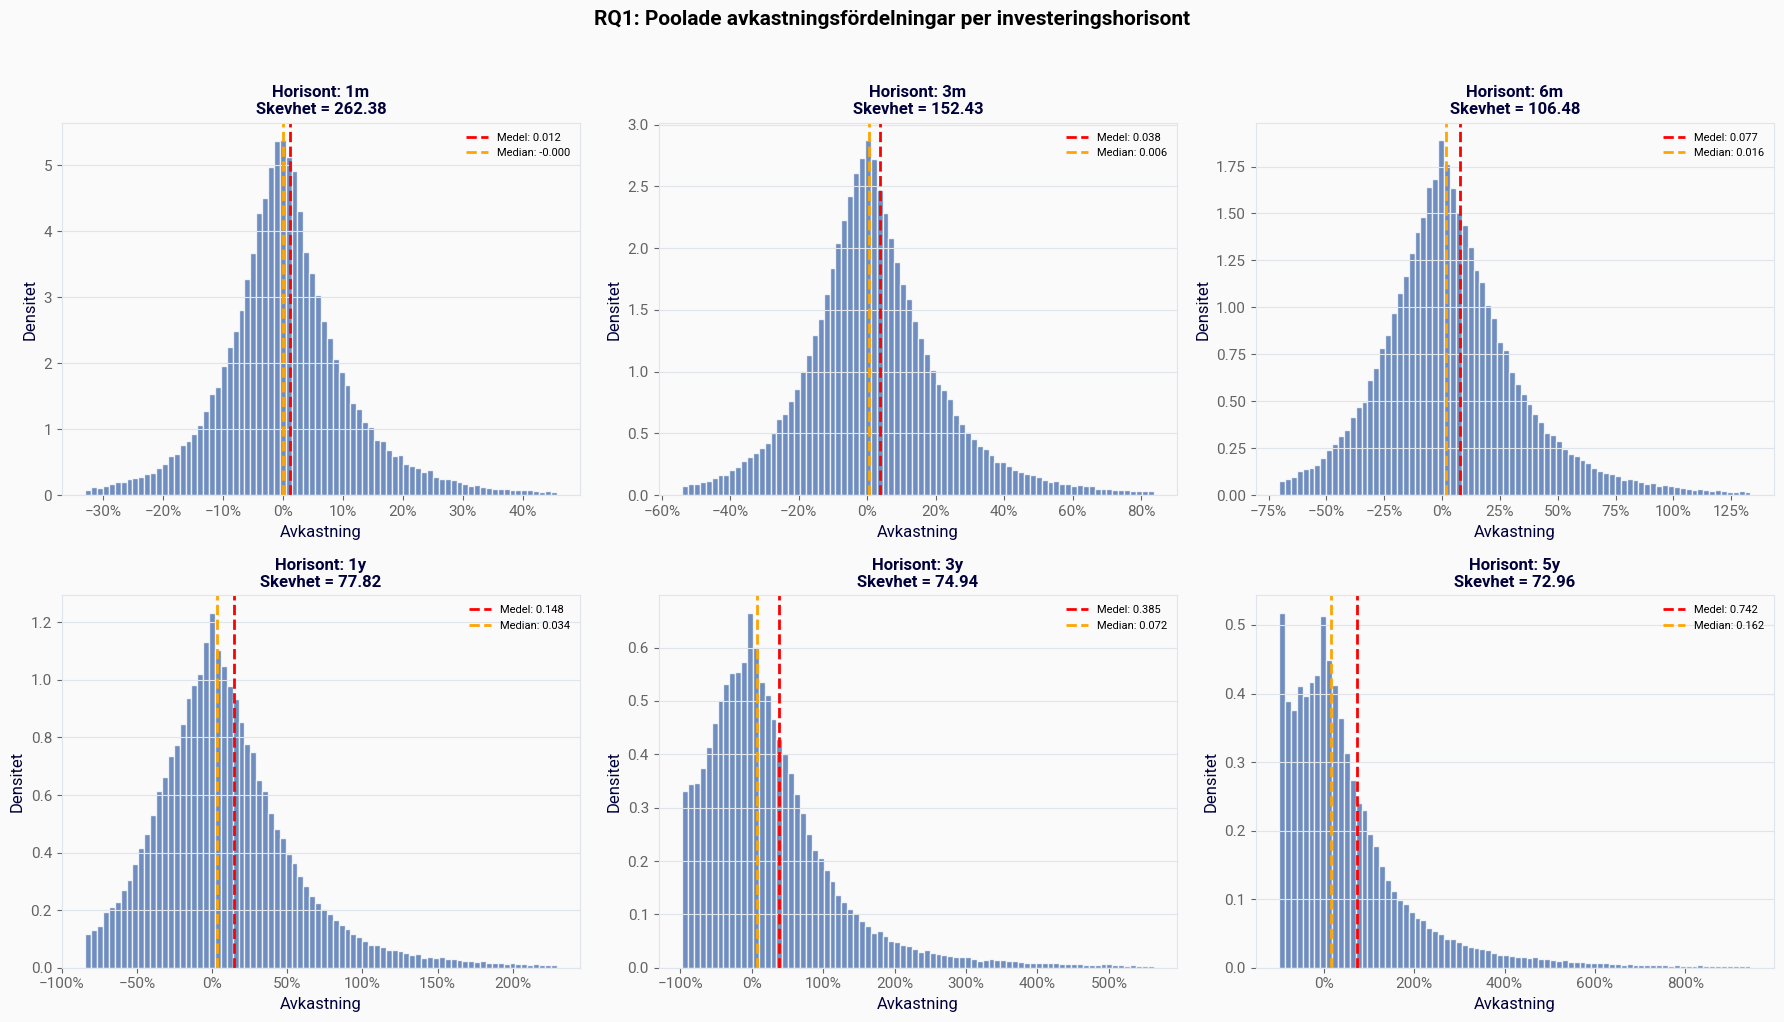

In [16]:
#=== RQ1: Visualisering av skevhet per horisont ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (label, h) in zip(axes.flat, horizons.items()):
    pooled = pooled_data[label]

    # Klipp extremvärden för snyggare graf
    q01, q99 = pooled.quantile(0.01), pooled.quantile(0.99)
    clipped = pooled[(pooled >= q01) & (pooled <= q99)]

    s =ax.hist(clipped, bins=80, color="#4C72B0", edgecolor="white", alpha=0.8, density=True)
    ax.axvline(pooled.mean(), color="red", ls="--", lw=2, label=f"Medel: {pooled.mean():.3f}")
    ax.axvline(pooled.median(), color="orange", ls="--", lw=2, label=f"Median: {pooled.median():.3f}")
    ax.set_title(f"Horisont: {label}\nSkevhet = {pooled.skew():.2f}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_xlabel("Avkastning")
    ax.set_ylabel("Densitet")
    ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1, decimals=0))

fig.suptitle("RQ1: Poolade avkastningsfördelningar per investeringshorisont",
             fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

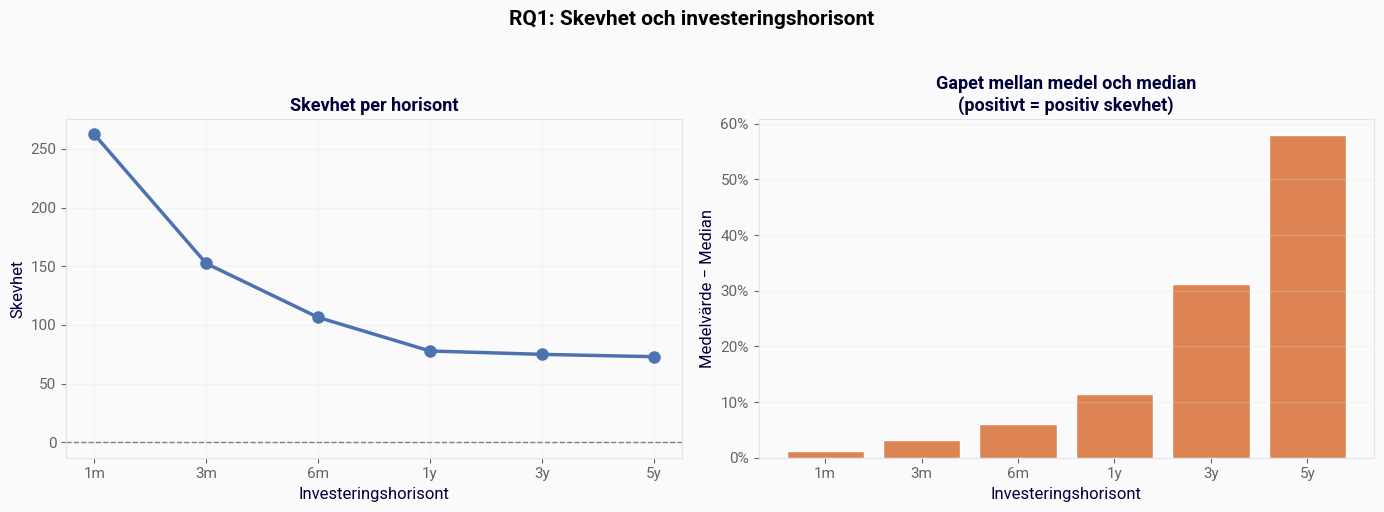

In [17]:
#=== RQ1: Skevhet som funktion av horisont ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

skew_values = [float(skew_results[k]["Skevhet"]) for k in horizons]
mean_median_gap = [float(skew_results[k]["Medel"]) - float(skew_results[k]["Median"]) for k in horizons]

# Panel 1: Skevhet
ax = axes[0]
ax.plot(list(horizons.keys()), skew_values, marker="o", lw=2.5, color="#4C72B0", markersize=8)
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("Investeringshorisont", fontsize=12)
ax.set_ylabel("Skevhet", fontsize=12)
ax.set_title("Skevhet per horisont", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3)

# Panel 2: Medel - Median gap
ax2 = axes[1]
ax2.bar(list(horizons.keys()), mean_median_gap, color="#DD8452", edgecolor="white")
ax2.set_xlabel("Investeringshorisont", fontsize=12)
ax2.set_ylabel("Medelvärde \u2212 Median", fontsize=12)
ax2.set_title("Gapet mellan medel och median\n(positivt = positiv skevhet)", fontsize=13, fontweight="bold")
ax2.grid(alpha=0.3, axis="y")
ax2.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1, decimals=0))

fig.suptitle("RQ1: Skevhet och investeringshorisont", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

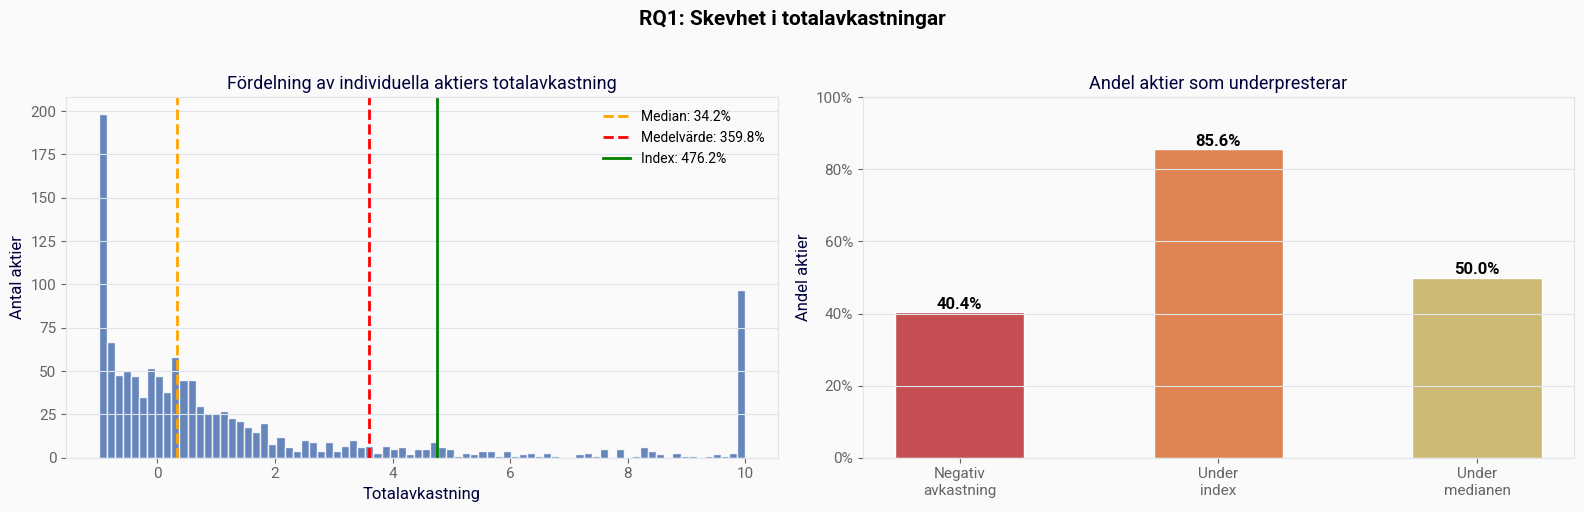

Skevhet (totalavkastning):  11.74
Kurtosis (totalavkastning): 178.09
Andel aktier med negativ totalavkastning: 40.4%
Andel aktier som underpresterar index:     85.6%


In [18]:
CLIP_RETURN_VALUE = 10
#=== RQ1: Totalavkastningsfördelning (hela perioden) ===
total_returns = (1 + AVKASTNINGAR).prod() - 1
total_returns_clip = total_returns.clip(-100000,CLIP_RETURN_VALUE)
index_total_return = (1 + index_avkastning).prod() - 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
ax = axes[0]
ax.hist(total_returns_clip.dropna().values, bins=80, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(total_returns.median(), color="orange", ls="--", lw=2, label=f"Median: {total_returns.median():.1%}")
ax.axvline(total_returns.mean(), color="red", ls="--", lw=2, label=f"Medelvärde: {total_returns.mean():.1%}")
ax.axvline(index_total_return, color="green", ls="-", lw=2, label=f"Index: {index_total_return:.1%}")
ax.set_xlabel("Totalavkastning", fontsize=12)
ax.set_ylabel("Antal aktier", fontsize=12)
ax.set_title("Fördelning av individuella aktiers totalavkastning", fontsize=13)
ax.legend(fontsize=10)


# Andel som underpresterar
share_below_index = (total_returns < index_total_return).mean()
share_below_zero = (total_returns < 0).mean()
share_below_median = 0.5

categories = ["Negativ\navkastning", "Under\nindex", "Under\nmedianen"]
values = [share_below_zero, share_below_index, share_below_median]
colors = ["#C44E52", "#DD8452", "#CCB974"]
ax2 = axes[1]
bars = ax2.bar(categories, values, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.1%}", ha="center", fontsize=12, fontweight="bold")
ax2.set_ylim(0, 1)
ax2.set_ylabel("Andel aktier", fontsize=12)
ax2.set_title("Andel aktier som underpresterar", fontsize=13)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

fig.suptitle("RQ1: Skevhet i totalavkastningar", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print(f"Skevhet (totalavkastning):  {total_returns.skew():.2f}")
print(f"Kurtosis (totalavkastning): {total_returns.kurtosis():.2f}")
print(f"Andel aktier med negativ totalavkastning: {share_below_zero:.1%}")
print(f"Andel aktier som underpresterar index:     {share_below_index:.1%}")

---
# 5. RQ2: Koncentration av värdeskapande

1. **Lorenzkurva** — visuell jämförelse med jämn fördelning
2. **Gini-koefficient** — kvantifierar ojämnheten (0 = helt jämnt, 1 = maximalt koncentrerat)
3. **Shannon-entropi** — mäter diversiteten i värdeskapande (normaliserad: 1 = helt jämnt)
4. **Theil-index** — dekomponerbart ojämlikhetsmått (GE(1), 0 = helt jämnt)

In [19]:
#=== RQ2: Hjälpfunktioner för koncentrationsanalys ===

def gini_coefficient(x):
    """Beräkna Gini-koefficient. 0 = helt jämnt, 1 = maximalt ojämnt."""
    x = np.sort(np.abs(np.array(x, dtype=float)))
    n = len(x)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * x) - (n + 1) * np.sum(x)) / (n * np.sum(x))

def shannon_entropy(x):
    """Shannon-entropi av fördelningen. Högre = mer jämnt fördelat."""
    x = np.abs(np.array(x, dtype=float))
    w = x / x.sum()
    w = w[w > 0]
    return -np.sum(w * np.log(w))

def theil_index(x):
    """Theil T-index (Generalized Entropy, α=1). 0 = helt jämnt."""
    x = np.array(x, dtype=float)
    x = x[x > 0]
    mu = x.mean()
    return float(np.mean((x / mu) * np.log(x / mu)))

def max_entropy(n):
    """Maximal Shannon-entropi för n element (= likfördelning)."""
    return np.log(n)

C:\Users\JonasAnderssonTuomaa\AppData\Local\Temp\ipykernel_3796\531252634.py:67: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Roboto.
  fig.tight_layout()
C:\Users\JonasAnderssonTuomaa\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Roboto.
  fig.canvas.print_figure(bytes_io, **kw)


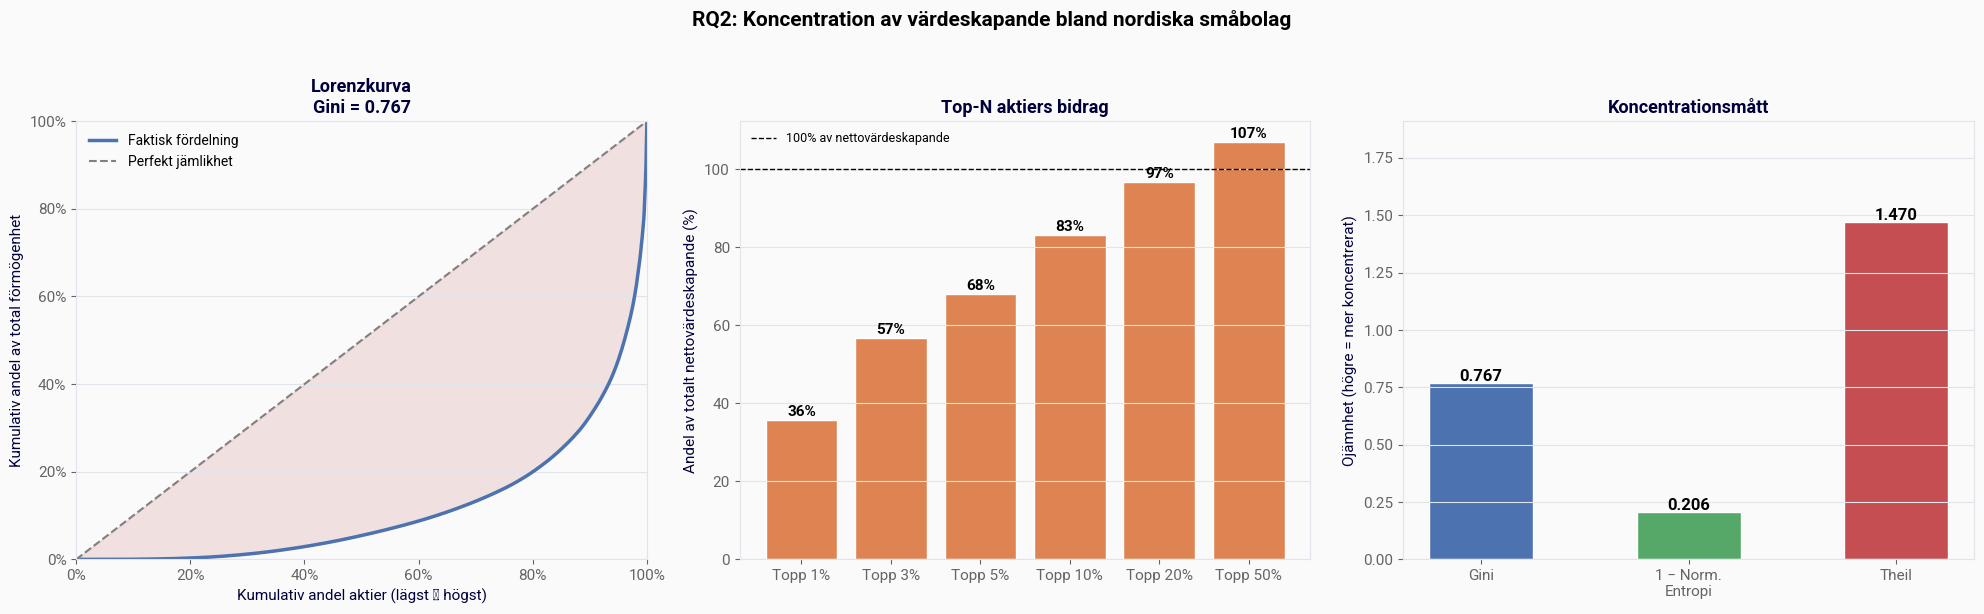


RQ2 — KONCENTRATIONSANALYS
Antal aktier:              1253
Gini-koefficient:          0.7673
Shannon-entropi:           5.66 (max = 7.13)
Normaliserad entropi:      0.7940
Theil-index:               1.4696

Andel med positiv avkastning: 59.6%
Andel som slår index:         14.4%
Topp  1% ( 12 aktier) →  35.8% av nettovärdeskapande
Topp  5% ( 62 aktier) →  68.0% av nettovärdeskapande
Topp 10% (125 aktier) →  83.2% av nettovärdeskapande
Topp 25% (313 aktier) → 100.2% av nettovärdeskapande


In [20]:
#=== RQ2: Koncentrationsanalys ===
sorted_returns = total_returns.dropna().sort_values(ascending=False)
n_stocks = len(sorted_returns)
wealth_per_stock = (1 + sorted_returns)
total_wealth_created = wealth_per_stock.sum() - n_stocks

# --- Beräkna koncentrationsmått ---
gini = gini_coefficient(wealth_per_stock.values)
entropy = shannon_entropy(wealth_per_stock.values)
entropy_max = max_entropy(n_stocks)
entropy_normalized = entropy / entropy_max
theil = theil_index(wealth_per_stock.values)

# --- Visualisering ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Lorenzkurva
ax = axes[0]
sorted_wealth = np.sort(wealth_per_stock.values)
cumulative_share = np.cumsum(sorted_wealth) / sorted_wealth.sum()
pct_stocks = np.arange(1, n_stocks + 1) / n_stocks
ax.plot(pct_stocks, cumulative_share, color="#4C72B0", lw=2.5, label="Faktisk fördelning")
ax.plot([0, 1], [0, 1], color="gray", ls="--", lw=1.5, label="Perfekt jämlikhet")
ax.fill_between(pct_stocks, cumulative_share, pct_stocks, alpha=0.15, color="#C44E52")
ax.set_xlabel("Kumulativ andel aktier (lägst \u2192 högst)", fontsize=11)
ax.set_ylabel("Kumulativ andel av total förmögenhet", fontsize=11)
ax.set_title(f"Lorenzkurva\nGini = {gini:.3f}", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1, decimals=0))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1, decimals=0))
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Panel 2: Top-N bidrag
ax2 = axes[1]
cutoffs = [1, 3, 5, 10, 20, 50]
top_contributions = []
for c in cutoffs:
    idx = max(1, int(n_stocks * c / 100))
    top_wealth = (wealth_per_stock.iloc[:idx] - 1).sum()
    top_contributions.append(top_wealth / total_wealth_created * 100)
bars = ax2.bar([f"Topp {c}%" for c in cutoffs], top_contributions,
               color="#DD8452", edgecolor="white")
for bar, val in zip(bars, top_contributions):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.0f}%", ha="center", fontsize=11, fontweight="bold")
ax2.axhline(100, color="black", ls="--", lw=1, label="100% av nettovärdeskapande")
ax2.set_ylabel("Andel av totalt nettovärdeskapande (%)", fontsize=11)
ax2.set_title("Top-N aktiers bidrag", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9)

# Panel 3: Koncentrationsmått (stapeldiagram)
ax3 = axes[2]
measures = ["Gini", "1 \u2212 Norm.\nEntropi", "Theil"]
conc_values = [gini, 1 - entropy_normalized, theil]
colors = ["#4C72B0", "#55A868", "#C44E52"]
bars3 = ax3.bar(measures, conc_values, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars3, conc_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", fontsize=12, fontweight="bold")
ax3.set_ylabel("Ojämnhet (högre = mer koncentrerat)", fontsize=11)
ax3.set_title("Koncentrationsmått", fontsize=13, fontweight="bold")
ax3.set_ylim(0, max(conc_values) * 1.3)

fig.suptitle("RQ2: Koncentration av värdeskapande bland nordiska småbolag",
             fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# --- Sammanfattning ---
print(f"\n{'='*60}")
print(f"RQ2 — KONCENTRATIONSANALYS")
print(f"{'='*60}")
print(f"Antal aktier:              {n_stocks}")
print(f"Gini-koefficient:          {gini:.4f}")
print(f"Shannon-entropi:           {entropy:.2f} (max = {entropy_max:.2f})")
print(f"Normaliserad entropi:      {entropy_normalized:.4f}")
print(f"Theil-index:               {theil:.4f}")
print()
print(f"Andel med positiv avkastning: {(sorted_returns > 0).mean():.1%}")
print(f"Andel som slår index:         {(sorted_returns > index_total_return).mean():.1%}")
for c in [1, 5, 10, 25]:
    idx = max(1, int(n_stocks * c / 100))
    tw = (wealth_per_stock.iloc[:idx] - 1).sum() / total_wealth_created * 100
    print(f"Topp {c:>2}% ({idx:>3} aktier) \u2192 {tw:>5.1f}% av nettovärdeskapande")

---
## 6. RQ3: Portföljkonstruktionens påverkan på avkastningsfördelningen

## Teoretisk bakgrund

### Vilka portföljer är att föredra - Preferensteori och skevhet

Standard riskjusterad avkastning definieras som:

$$U_{\text{standard}} = \mu - \lambda \, \sigma^2$$

där $\mu$ = förväntad avkastning, $\sigma^2$ = varians, och $\lambda$ = riskaversion.
Denna modell ignorerar dock högre moment. Scott & Horvath (1980) och Harvey & Siddique (2000)
visar att investerare har preferenser för positiv skevhet. En utökad nyttofunktion:

$$U = \mu - \lambda \, \sigma^2 + \gamma \cdot S$$

där $S$ = skevhet och $\gamma > 0$ fångar preferensen för positiv skevhet ("lotterieffekten").
Vi evaluerar portföljkonfigurationer med $\lambda = 2$ och $\gamma \in \{0,\, 0.5,\, 1.0,\, 2.0\}$.

### Skill-modellering

Vi modellerar förvaltarskicklighet som en *bias* i urvalssannolikhet: aktier med historiskt
hög avkastning (topp-tredjedel) ges sannolikheten $(1 + \text{bias})$, medan bottentredjedelen
ges $\max(1 - \text{bias},\, 0)$. Parametern `bias ∈ [0, 1]` representerar en gradient från
oinformerat till gradvis mer informerat urval.

Denna ansats kan relateras till Grinold & Kahns *Information Coefficient* (IC) — korrelationen
mellan förvaltarens ranking och faktisk avkastning. Vår bias-parameter är en förenklad proxy
för IC, tillämpad asymmetriskt på avkastningsfördelningens svansar.

### Viktningsscheman

Vi jämför likaviktning ($\alpha = 0$) och börsvärdeviktning ($\alpha = 1$) och hybrider däremellan, där vikterna
ges av $w_i \propto \text{mcap}_i^{\alpha}$.

Fernholz (2002) *Stochastic Portfolio Theory* visar att likaviktning kan generera en
systematisk "rebalanseringsbonus" genom volatilitetsskillnader mellan aktier.

## 6.1 Portföljstorlek (koncentration)

Portföljkoncentration är den mest grundläggande dimensionen. Med positivt skeva
avkastningsfördelningar innebär högre koncentration:

- **Bredare utfallsfördelning** — båda svansarna förstärks
- **Ökad positiv skevhet** — asymmetrin i underliggande avkastningar förstärks
- **Lägre sannolikhet att slå index** — medianen faller under medelvärdet


** **


**Parametrar**
- *bias_val* : Variera skill parameter
- *prob_val* : Variera sannolikehet för urval baserat på storlek (0 alla bolag lika sannolika, 1: sannolikhet proportionerlig mot vikt) 
- *weight_val* : Viktning: (1 Markandadsvärde, 0 rak viktad)

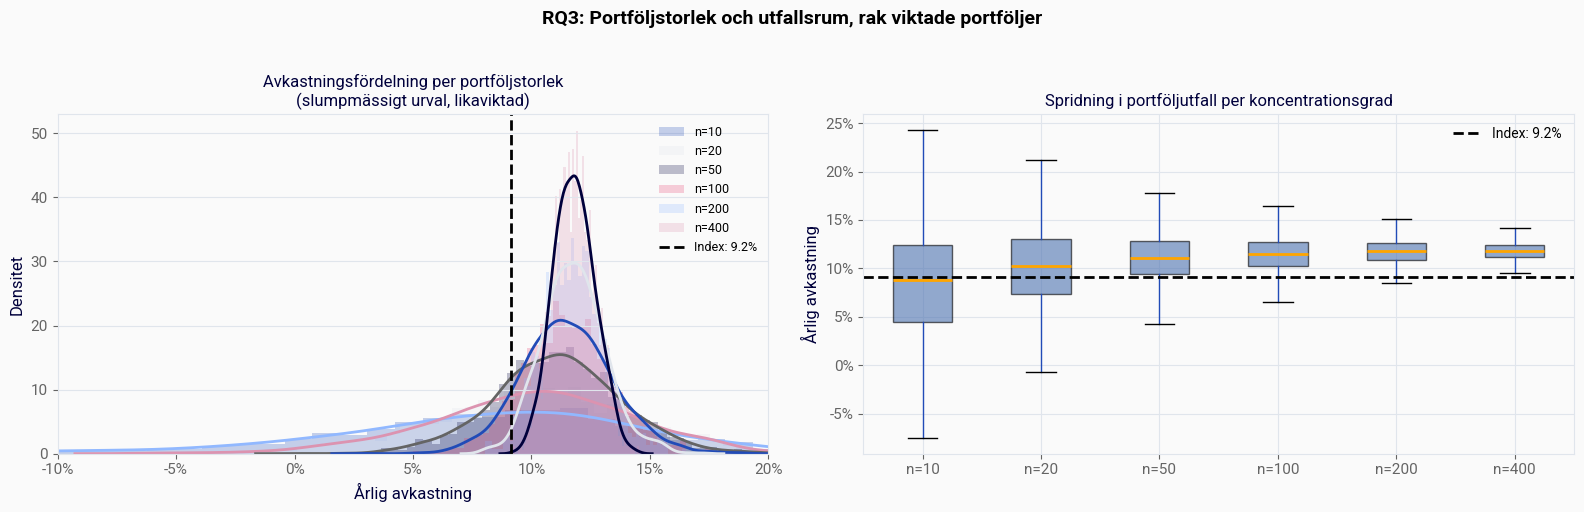

In [21]:
# === RQ3a: Avkastningsfördelning per portföljstorlek, rak vikt ===

bias_val, prob_val, weight_val = 0.0, 0.0, 0.0 # Här kan man välja parametrar



subset = result["Return"].loc[pd.IndexSlice[:, bias_val, prob_val, weight_val]]
pf_sizes = sorted(subset.index.get_level_values(0).unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KDE (subsampla till 5000 för snabbare KDE)
ax = axes[0]
for pf_size in pf_sizes:
    vals = subset.loc[pf_size].values.flatten()
    vals = vals[~np.isnan(vals)]
    ax.hist(vals, bins=60, alpha=0.25, label=f"n={int(pf_size)}", density=True)
    sample = vals if len(vals) <= 5000 else np.random.choice(vals, 5000, replace=False)
    sns.kdeplot(sample, ax=ax, lw=2, label=None)
ax.axvline(index_kfs["Return"], color="black", ls="--", lw=2, label=f"Index: {index_kfs['Return']:.1%}")
ax.set_xlabel("Årlig avkastning", fontsize=12)
ax.set_ylabel("Densitet", fontsize=12)
ax.set_title("Avkastningsfördelning per portföljstorlek\n(slumpmässigt urval, likaviktad)", fontsize=12)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_xlim(-0.1,0.2)

# Boxplot
ax2 = axes[1]
box_data = {f"n={int(k)}": subset.loc[k].values.flatten() for k in pf_sizes}
data_for_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in box_data.items()]))
data_for_box.boxplot(ax=ax2, vert=True, patch_artist=True,
                     boxprops=dict(facecolor="#4C72B0", alpha=0.6),
                     medianprops=dict(color="orange", lw=2),
                     showfliers=False)
ax2.axhline(index_kfs["Return"], color="black", ls="--", lw=2, label=f"Index: {index_kfs['Return']:.1%}")
ax2.set_ylabel("Årlig avkastning", fontsize=12)
ax2.set_title("Spridning i portföljutfall per koncentrationsgrad", fontsize=12)
ax2.legend(fontsize=10)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

fig.suptitle("RQ3: Portföljstorlek och utfallsrum, rak viktade portföljer", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

In [22]:
# === RQ3a: Statistik per portföljstorlek ===

bias_val, prob_val, weight_val = 0.0, 0.0, 1.0

kfs = ["Return", "Vol", "Information Ratio", "Skew", "Max DrawDown"]
pf_sizes_list = sorted(result.index.get_level_values(0).unique())

stats_by_size = {kf: {} for kf in kfs}
for pf_s in pf_sizes_list:
    for kf in kfs:
        try:
            v = result[kf].loc[pd.IndexSlice[pf_s, bias_val, prob_val, weight_val]].values.flatten()
            v = v[~np.isnan(v)]
            stats_by_size[kf][int(pf_s)] = {
                "Medel": np.mean(v), "Median": np.median(v), "Std": np.std(v),
                "P10": np.percentile(v, 10), "P90": np.percentile(v, 90),
            }
        except KeyError:
            pass

for kf in kfs:
    stats_by_size[kf] = pd.DataFrame(stats_by_size[kf]).T

p_beat_vals = {}
for pf_s in pf_sizes_list:
    try:
        v = result["Return"].loc[pd.IndexSlice[pf_s, bias_val, prob_val, weight_val]].values.flatten()
        p_beat_vals[int(pf_s)] = np.mean(v > index_kfs["Return"])
    except KeyError:
        pass
p_beat = pd.Series(p_beat_vals)

summary_table = pd.DataFrame({
    "Medel avk.": stats_by_size["Return"]["Medel"],
    "Median avk.": stats_by_size["Return"]["Median"],
    "Std avk.": stats_by_size["Return"]["Std"],
    "Medel IR": stats_by_size["Information Ratio"]["Medel"],
    "Medel skevhet": stats_by_size["Skew"]["Medel"],
    "P(slå index)": p_beat,
    "Medel Max DD": stats_by_size["Max DrawDown"]["Medel"],
})
summary_table.index = [f"n={i}" for i in summary_table.index]
summary_table.style.format({
    "Medel avk.": "{:.2%}", "Median avk.": "{:.2%}", "Std avk.": "{:.2%}",
    "Medel IR": "{:.2f}", "Medel skevhet": "{:.2f}",
    "P(slå index)": "{:.1%}", "Medel Max DD": "{:.1%}"
}).background_gradient(subset=["P(slå index)"], cmap="RdYlGn").set_caption(f"Parametrar: bias={bias_val}, selection={prob_val}, weighting={weight_val}")



,Medel avk.,Median avk.,Std avk.,Medel IR,Medel skevhet,P(slå index),Medel Max DD
n=10,6.25%,7.08%,7.31%,0.25,0.19,37.9%,70.2%
n=20,7.55%,8.01%,4.63%,0.33,-0.16,38.9%,64.2%
n=50,8.56%,8.88%,2.93%,0.42,-0.39,45.1%,59.5%
n=100,8.81%,8.98%,1.94%,0.47,-0.49,46.0%,57.9%
n=200,9.02%,9.14%,1.30%,0.50,-0.57,49.8%,56.9%
n=400,9.12%,9.18%,0.83%,0.52,-0.63,50.8%,56.4%


## 6.2 Informerat urval (skill)

Parametern `bias` styr i vilken grad urvalssannolikheterna skiljer aktier med historiskt hög
avkastning från övriga. Här studerar vi hur ökad bias påverkar fördelningen av portföljutfall, sannolikheten att slå
index, samt relationen mellan avkastning och risk.

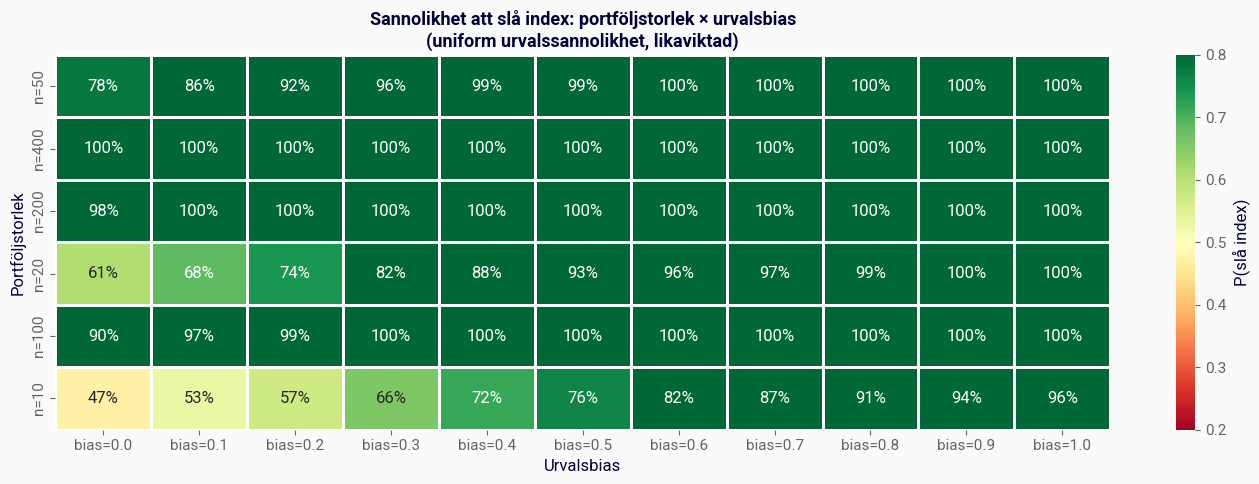

In [23]:
# === RQ3b: Heatmap — P(slå index) som funktion av pf_size och bias ===
prob_val, weight_val = 0.0, 0.0
bias_levels_all = sorted(result.index.get_level_values("bias").unique())

heatmap_data = {}
for pf_s in pf_sizes_list:
    row = {}
    for b in bias_levels_all:
        try:
            v = result["Return"].loc[pd.IndexSlice[pf_s, b, prob_val, weight_val]].values.flatten()
            row[f"bias={b}"] = np.mean(v > index_kfs["Return"])
        except KeyError:
            row[f"bias={b}"] = np.nan
    heatmap_data[f"n={int(pf_s)}"] = row
p_beat_matrix = pd.DataFrame(heatmap_data).T

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    p_beat_matrix.sort_index(ascending=False),
    annot=True, fmt=".0%", cmap="RdYlGn", center=0.5,
    linewidths=1, ax=ax, vmin=0.2, vmax=0.8,
    cbar_kws={"label": "P(slå index)"}
)
ax.set_title("Sannolikhet att slå index: portföljstorlek × urvalsbias\n(uniform urvalssannolikhet, likaviktad)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Urvalsbias", fontsize=12)
ax.set_ylabel("Portföljstorlek", fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.show()

### 6.3 Viktningsscheman: från likaviktad till börsvärdeviktad

Vi varierar $w_i \propto \text{mcap}_i^{\alpha}$ med $\alpha \in \{0, 0.25, 0.5, 0.75, 1.0\}$
och tre urvalssannolikheter (`prob_exp` $\in \{0, 0.5, 1\}$), utan bias.

C:\Users\JonasAnderssonTuomaa\AppData\Local\Temp\ipykernel_3796\643795153.py:63: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Roboto.
  fig.tight_layout()
C:\Users\JonasAnderssonTuomaa\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Roboto.
  fig.canvas.print_figure(bytes_io, **kw)


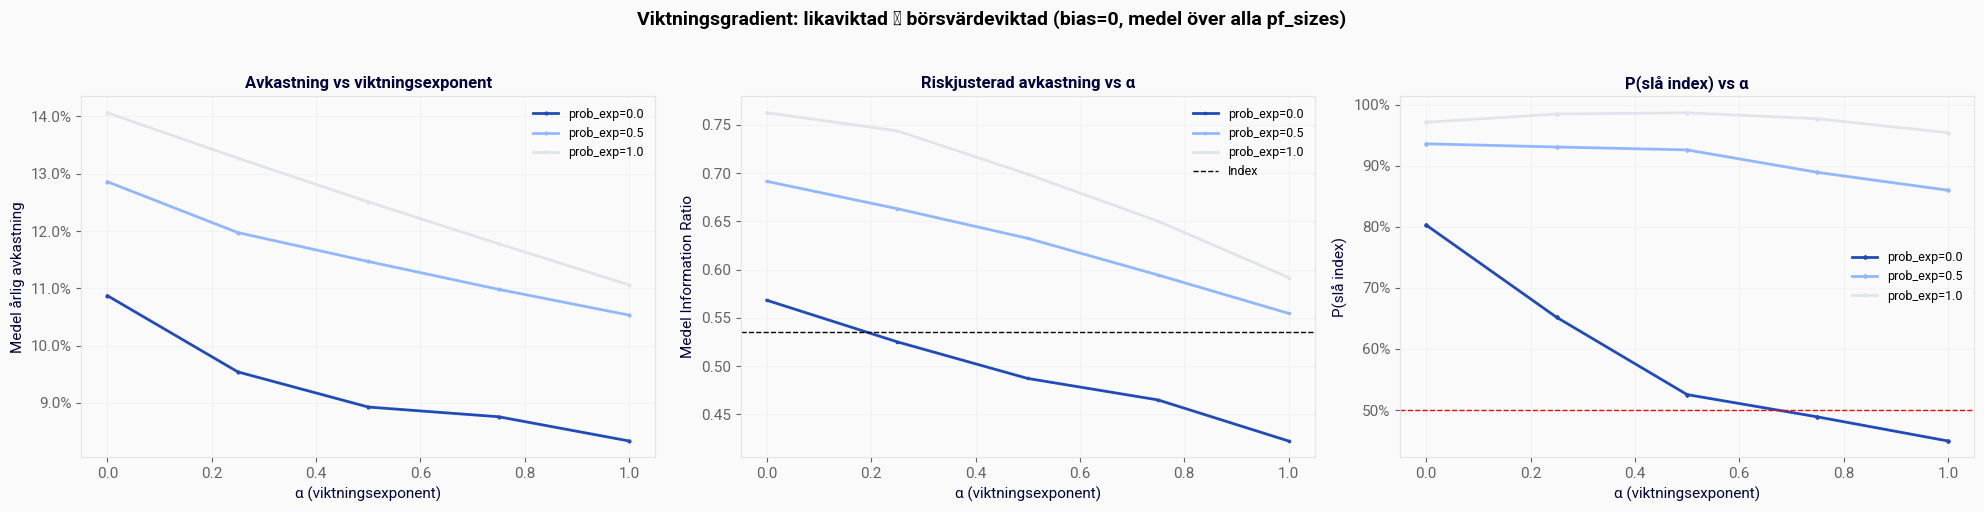

In [24]:
# === RQ3c: Viktningsgradient — avkastning, IR och P(slå index) ===
bias_val = 0.0
wt_values = [0.0, 0.25, 0.5, 0.75, 1.0]
wt_labels = {0.0: "α=0 (lika)", 0.25: "α=0.25", 0.5: "α=0.5", 0.75: "α=0.75", 1.0: "α=1 (mcap)"}
prob_values = sorted(result.index.get_level_values(2).unique())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: Medel avkastning per α, uppdelat på prob_exp
for prob in prob_values:
    means = []
    for wt in wt_values:
        try:
            sub = result["Return"].loc[pd.IndexSlice[:, bias_val, prob, wt]]
            means.append(sub.mean(axis=1).mean())
        except KeyError:
            means.append(np.nan)
    axes[0].plot(wt_values, means, marker="o", lw=2, label=f"prob_exp={prob}")
axes[0].set_xlabel("α (viktningsexponent)", fontsize=11)
axes[0].set_ylabel("Medel årlig avkastning", fontsize=11)
axes[0].set_title("Avkastning vs viktningsexponent", fontsize=12, fontweight="bold")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Panel 2: Medel IR per α
for prob in prob_values:
    irs = []
    for wt in wt_values:
        try:
            sub = result["Information Ratio"].loc[pd.IndexSlice[:, bias_val, prob, wt]]
            irs.append(sub.mean(axis=1).mean())
        except KeyError:
            irs.append(np.nan)
    axes[1].plot(wt_values, irs, marker="s", lw=2, label=f"prob_exp={prob}")
axes[1].axhline(index_kfs["Information Ratio"], color="black", ls="--", lw=1, label="Index")
axes[1].set_xlabel("α (viktningsexponent)", fontsize=11)
axes[1].set_ylabel("Medel Information Ratio", fontsize=11)
axes[1].set_title("Riskjusterad avkastning vs α", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Panel 3: P(slå index) per α
for prob in prob_values:
    ps = []
    for wt in wt_values:
        try:
            sub = result["Return"].loc[pd.IndexSlice[:, bias_val, prob, wt]]
            ps.append(sub.gt(index_kfs["Return"]).mean(axis=1).mean())
        except KeyError:
            ps.append(np.nan)
    axes[2].plot(wt_values, ps, marker="D", lw=2, label=f"prob_exp={prob}")
axes[2].axhline(0.5, color="red", ls="--", lw=1)
axes[2].set_xlabel("α (viktningsexponent)", fontsize=11)
axes[2].set_ylabel("P(slå index)", fontsize=11)
axes[2].set_title("P(slå index) vs α", fontsize=12, fontweight="bold")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

fig.suptitle("Viktningsgradient: likaviktad → börsvärdeviktad (bias=0, medel över alla pf_sizes)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

In [25]:
# index levels i sepaata variabler och sorterade
bias_levels = sorted(result.index.get_level_values("bias").unique())
wt_levels = sorted(result.index.get_level_values("weights_exp").unique())
prob_levels = sorted(result.index.get_level_values("prob_exp").unique())

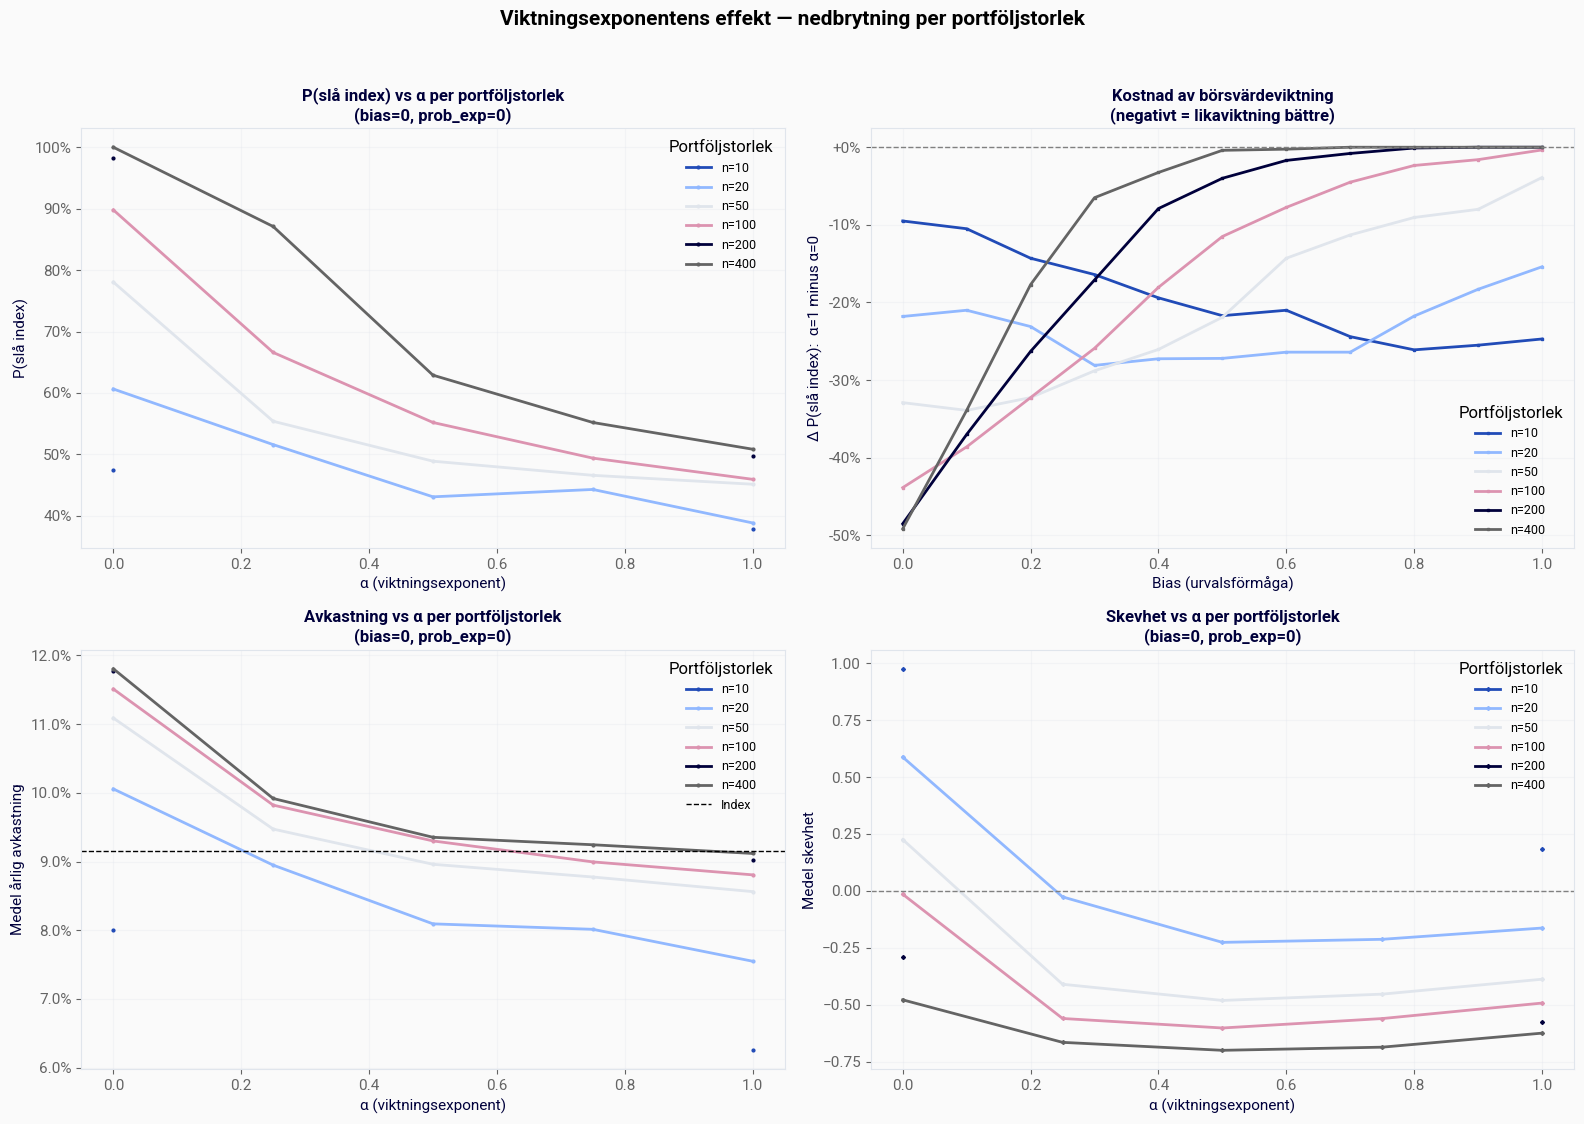

In [26]:
# === Viktningseffekt per portföljstorlek ===
# Visar om likaviktning är viktigare för koncentrerade eller diversifierade portföljer

pf_sizes_list = sorted(result.index.get_level_values("pf_size").unique())
selected_sizes = [s for s in [10, 20, 50, 100, 200, 400] if s in pf_sizes_list]
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# --- Panel 1: P(slå index) vs α, per pf_size (bias=0, prob_exp=0) ---
ax = axes[0, 0]
for pf_s in selected_sizes:
    ps = []
    for wt in wt_levels:
        try:
            v = result["Return"].loc[pd.IndexSlice[pf_s, 0.0, 0.0, wt]].values.flatten()
            ps.append(float(np.mean(v > index_kfs["Return"])))
        except KeyError:
            ps.append(np.nan)
    ax.plot(wt_levels, ps, marker="o", lw=2, label=f"n={int(pf_s)}")
ax.set_xlabel("α (viktningsexponent)", fontsize=11)
ax.set_ylabel("P(slå index)", fontsize=11)
ax.set_title("P(slå index) vs α per portföljstorlek\n(bias=0, prob_exp=0)", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=9, title="Portföljstorlek")
ax.grid(alpha=0.3)

# --- Panel 2: Δ P(slå index) från α=0 till α=1, per pf_size & bias ---
ax2 = axes[0, 1]
for pf_s in selected_sizes:
    deltas = []
    for b in bias_levels:
        try:
            v0 = result["Return"].loc[pd.IndexSlice[pf_s, b, 0.0, 0.0]].values.flatten()
            v1 = result["Return"].loc[pd.IndexSlice[pf_s, b, 0.0, 1.0]].values.flatten()
            deltas.append(float(np.mean(v1 > index_kfs["Return"]) - np.mean(v0 > index_kfs["Return"])))
        except KeyError:
            deltas.append(np.nan)
    ax2.plot(bias_levels, deltas, marker="s", lw=2, label=f"n={int(pf_s)}")
ax2.axhline(0, color="gray", ls="--", lw=1)
ax2.set_xlabel("Bias (urvalsförmåga)", fontsize=11)
ax2.set_ylabel("Δ P(slå index):  α=1 minus α=0", fontsize=11)
ax2.set_title("Kostnad av börsvärdeviktning\n(negativt = likaviktning bättre)", fontsize=12, fontweight="bold")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.0%}"))
ax2.legend(fontsize=9, title="Portföljstorlek")
ax2.grid(alpha=0.3)

# --- Panel 3: Medel avkastning vs α, per pf_size (bias=0, prob=0) ---
ax3 = axes[1, 0]
for pf_s in selected_sizes:
    ms = []
    for wt in wt_levels:
        try:
            v = result["Return"].loc[pd.IndexSlice[pf_s, 0.0, 0.0, wt]].values.flatten()
            ms.append(float(np.nanmean(v)))
        except KeyError:
            ms.append(np.nan)
    ax3.plot(wt_levels, ms, marker="o", lw=2, label=f"n={int(pf_s)}")
ax3.axhline(index_kfs["Return"], color="black", ls="--", lw=1, label="Index")
ax3.set_xlabel("α (viktningsexponent)", fontsize=11)
ax3.set_ylabel("Medel årlig avkastning", fontsize=11)
ax3.set_title("Avkastning vs α per portföljstorlek\n(bias=0, prob_exp=0)", fontsize=12, fontweight="bold")
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
ax3.legend(fontsize=9, title="Portföljstorlek")
ax3.grid(alpha=0.3)

# --- Panel 4: Skevhet vs α, per pf_size ---
ax4 = axes[1, 1]
for pf_s in selected_sizes:
    sk = []
    for wt in wt_levels:
        try:
            v = result["Skew"].loc[pd.IndexSlice[pf_s, 0.0, 0.0, wt]].values.flatten()
            sk.append(float(np.nanmean(v)))
        except KeyError:
            sk.append(np.nan)
    ax4.plot(wt_levels, sk, marker="D", lw=2, label=f"n={int(pf_s)}")
ax4.axhline(0, color="gray", ls="--", lw=1)
ax4.set_xlabel("α (viktningsexponent)", fontsize=11)
ax4.set_ylabel("Medel skevhet", fontsize=11)
ax4.set_title("Skevhet vs α per portföljstorlek\n(bias=0, prob_exp=0)", fontsize=12, fontweight="bold")
ax4.legend(fontsize=9, title="Portföljstorlek")
ax4.grid(alpha=0.3)

fig.suptitle("Viktningsexponentens effekt — nedbrytning per portföljstorlek",
             fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

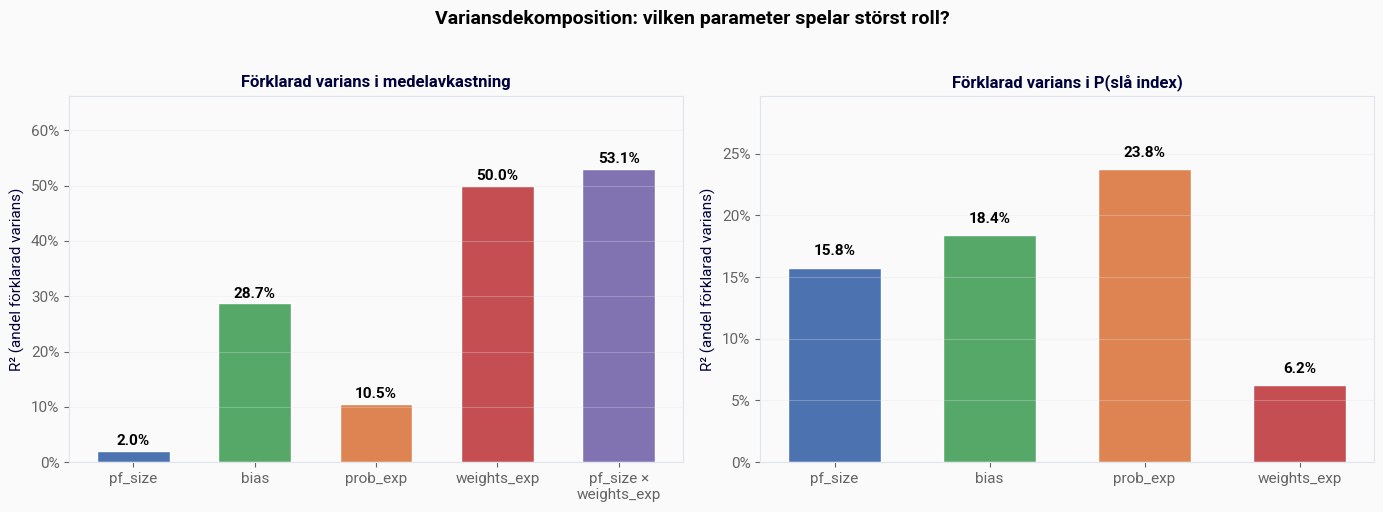


Parameter              R²(Avkastning)   R²(P beat)
--------------------------------------------------
pf_size                         2.0%       15.8%
bias                           28.7%       18.4%
prob_exp                       10.5%       23.8%
weights_exp                    50.0%        6.2%
pf_size×weights_exp            53.1%           —


In [27]:
# === Variansdekomposition: hur mycket förklarar varje parameter? Denna analys kom chatgpt på. Inte ritktigt koll på den teoretiska bakgrunden här===
# Beräknar andel av variansen i medel-avkastning som förklaras av
# pf_size, bias, prob_exp och weights_exp (enkel ANOVA-inspirerad ansats)

# Bygg en flat tabell: en rad per parameterkonfiguration, medelvärde av 1000 sims
rows_decomp = []
for (pf_s, b, prob, wt), sub in result["Return"].groupby(level=[0, 1, 2, 3]):
    rows_decomp.append({
        "pf_size": pf_s, "bias": b, "prob_exp": prob, "weights_exp": wt,
        "mean_ret": sub.mean(axis=1).values[0] if len(sub) == 1 else sub.mean(axis=1).mean(),
        "p_beat": sub.gt(index_kfs["Return"]).mean(axis=1).values[0] if len(sub) == 1 else sub.gt(index_kfs["Return"]).mean(axis=1).mean(),
    })
decomp_df = pd.DataFrame(rows_decomp)

total_var_ret = decomp_df["mean_ret"].var()
total_var_pbeat = decomp_df["p_beat"].var()

# Förklarad varians per faktor (R² från gruppmedelvärden)
factors = ["pf_size", "bias", "prob_exp", "weights_exp"]
r2_ret, r2_pbeat = {}, {}
for f in factors:
    group_means_ret = decomp_df.groupby(f)["mean_ret"].transform("mean")
    r2_ret[f] = 1 - (decomp_df["mean_ret"] - group_means_ret).var() / total_var_ret
    group_means_pb = decomp_df.groupby(f)["p_beat"].transform("mean")
    r2_pbeat[f] = 1 - (decomp_df["p_beat"] - group_means_pb).var() / total_var_pbeat

# Interaktion: pf_size × weights_exp
group_int = decomp_df.groupby(["pf_size", "weights_exp"])["mean_ret"].transform("mean")
r2_interaction = 1 - (decomp_df["mean_ret"] - group_int).var() / total_var_ret

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: R² för medelavkastning
ax = axes[0]
vals_ret = [r2_ret[f] for f in factors] + [r2_interaction]
labels_ret = ["pf_size", "bias", "prob_exp", "weights_exp", "pf_size ×\nweights_exp"]
colors_bar = ["#4C72B0", "#55A868", "#DD8452", "#C44E52", "#8172B2"]
bars = ax.bar(labels_ret, vals_ret, color=colors_bar, edgecolor="white", width=0.6)
for bar, val in zip(bars, vals_ret):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.1%}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("R² (andel förklarad varians)", fontsize=11)
ax.set_title("Förklarad varians i medelavkastning", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(vals_ret) * 1.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.grid(alpha=0.3, axis="y")

# Panel 2: R² för P(slå index)
ax2 = axes[1]
vals_pb = [r2_pbeat[f] for f in factors]
bars2 = ax2.bar(factors, vals_pb, color=colors_bar[:4], edgecolor="white", width=0.6)
for bar, val in zip(bars2, vals_pb):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.1%}", ha="center", fontsize=11, fontweight="bold")
ax2.set_ylabel("R² (andel förklarad varians)", fontsize=11)
ax2.set_title("Förklarad varians i P(slå index)", fontsize=12, fontweight="bold")
ax2.set_ylim(0, max(vals_pb) * 1.25)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax2.grid(alpha=0.3, axis="y")

fig.suptitle("Variansdekomposition: vilken parameter spelar störst roll?",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print(f"\n{'Parameter':<20} {'R²(Avkastning)':>16} {'R²(P beat)':>12}")
print("-" * 50)
for f in factors:
    print(f"{f:<20} {r2_ret[f]:>15.1%} {r2_pbeat[f]:>11.1%}")
print(f"{'pf_size×weights_exp':<20} {r2_interaction:>15.1%} {'—':>11}")

## 6.4 Nyttofunktion med skevhetspreferens

Standard Information Ratio (IR) missar skevhetsdimensionen. Investerare med preferens för
positiv skevhet (lotterilott-effekten) bör tillskriva ett mervärde till portföljkonfigurationer
som genererar positivt skeva utfallsfördelningar.

Vi beräknar en utökad nyttofunktion:

$$U = \mu - \lambda \, \sigma^2 + \gamma \cdot S$$


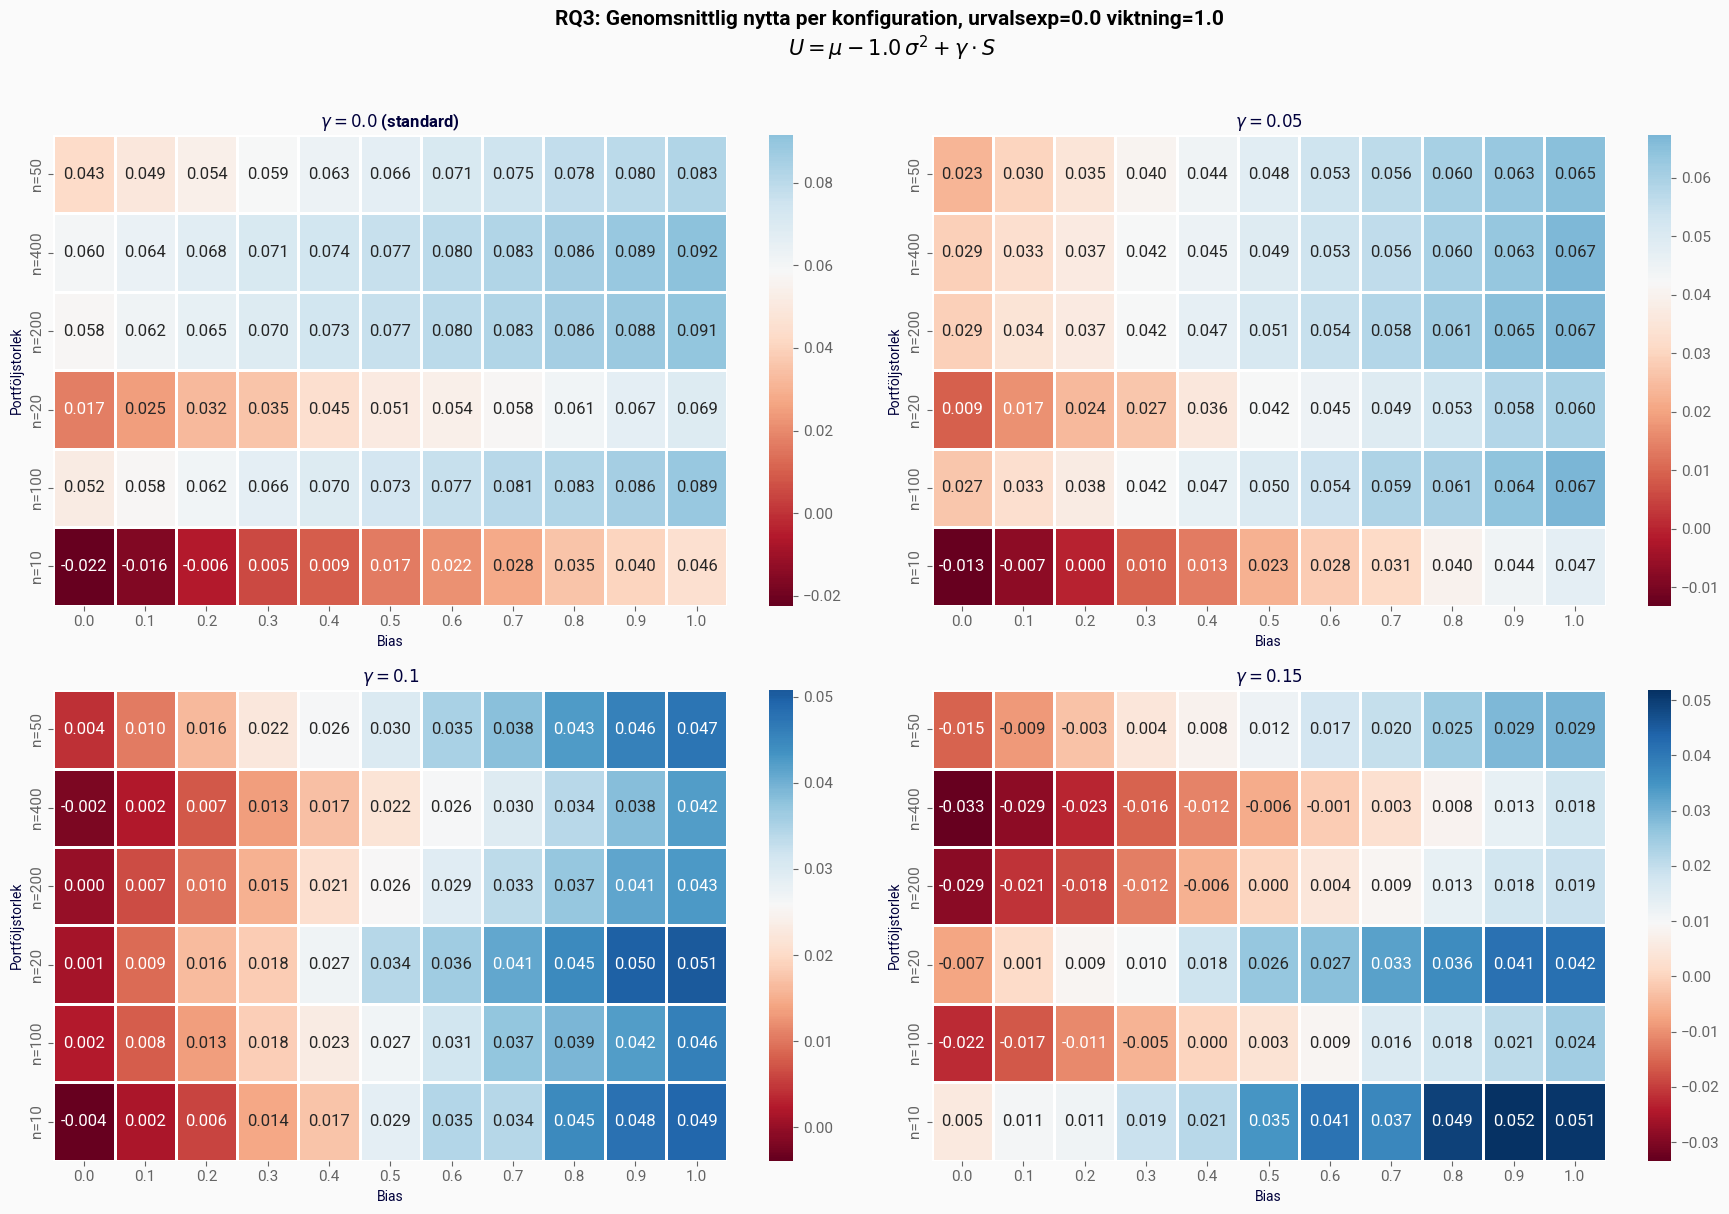


Optimal konfiguration per gamma-värde (urval=0.0, viktning=1.0):
  gamma=0.00: pf_size=400, bias=1.0  (U=0.0916)
  gamma=0.05: pf_size=100, bias=1.0  (U=0.0673)
  gamma=0.10: pf_size=20, bias=1.0  (U=0.0508)
  gamma=0.15: pf_size=10, bias=0.9  (U=0.0518)


In [28]:
# === RQ3d: Nyttofunktion med skevhetspreferens ===
LAMBDA = 1.0        # riskaversion
GAMMA_VALUES = [0.0, 0.05, 0.1, 0.15]  # skevhetspreferens

prob_val, weight_val = 0.0, 1.0
  

pf_sizes_u = sorted(result.index.get_level_values(0).unique())
bias_levels = sorted(result.index.get_level_values(1).unique())

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, gamma in zip(axes.flat, GAMMA_VALUES):
    grid = {}
    for b in bias_levels:
        col = []
        for pf_s in pf_sizes_u:
            try:
                r = result["Return"].loc[pd.IndexSlice[pf_s, b, prob_val, weight_val]].values.flatten()
                vol = result["Vol"].loc[pd.IndexSlice[pf_s, b, prob_val, weight_val]].values.flatten()
                skw = result["Skew"].loc[pd.IndexSlice[pf_s, b, prob_val, weight_val]].values.flatten()
                u = r - LAMBDA * vol**2 + gamma * skw
                col.append(float(np.nanmean(u)))
            except KeyError:
                col.append(np.nan)
        grid[f"{b:.1f}"] = col
    df = pd.DataFrame(grid, index=[f"n={int(s)}" for s in pf_sizes_u])

    sns.heatmap(
        df.sort_index(ascending=False),
        annot=True, fmt=".3f", cmap="RdBu", center=df.values.mean(),
        linewidths=1, ax=ax
    )
    ax.grid(False)
    ax.set_title(f"$\\gamma = {gamma}$" + (" (standard)" if gamma == 0 else ""),
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Bias", fontsize=10)
    ax.set_ylabel("Portföljstorlek", fontsize=10)

fig.suptitle(f"RQ3: Genomsnittlig nytta per konfiguration, urvalsexp={prob_val} viktning={weight_val} \n"
             f"$U = \\mu - {LAMBDA}\\,\\sigma^2 + \\gamma \\cdot S$",
             fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

# --- Visa hur optimal konfiguration skiftar med gamma ---
print(f"\nOptimal konfiguration per gamma-värde (urval={prob_val}, viktning={weight_val}):")
print("=" * 70)
for gamma in GAMMA_VALUES:
    best_u, best_cfg = -np.inf, None
    for b in bias_levels:
        for pf_s in pf_sizes_u:
            try:
                r = result["Return"].loc[pd.IndexSlice[pf_s, b, prob_val, weight_val]].values.flatten()
                vol = result["Vol"].loc[pd.IndexSlice[pf_s, b, prob_val, weight_val]].values.flatten()
                skw = result["Skew"].loc[pd.IndexSlice[pf_s, b, prob_val, weight_val]].values.flatten()
                u_mean = float(np.nanmean(r - LAMBDA * vol**2 + gamma * skw))
                if u_mean > best_u:
                    best_u = u_mean
                    best_cfg = (pf_s, b)
            except KeyError:
                pass
    if best_cfg:
        print(f"  gamma={gamma:.2f}: pf_size={best_cfg[0]:.0f}, bias={best_cfg[1]:.1f}  (U={best_u:.4f})")

## 6.5 Sammanställning: P(slå index) — alla dimensioner

Vi sammanställer huvudresultatet: **sannolikheten att en slumpmässigt konstruerad portfölj
slår index**, sett över alla kombinationer av portföljstorlek, urvalsbias, urvalssannolikhet
och viktningsmetod.

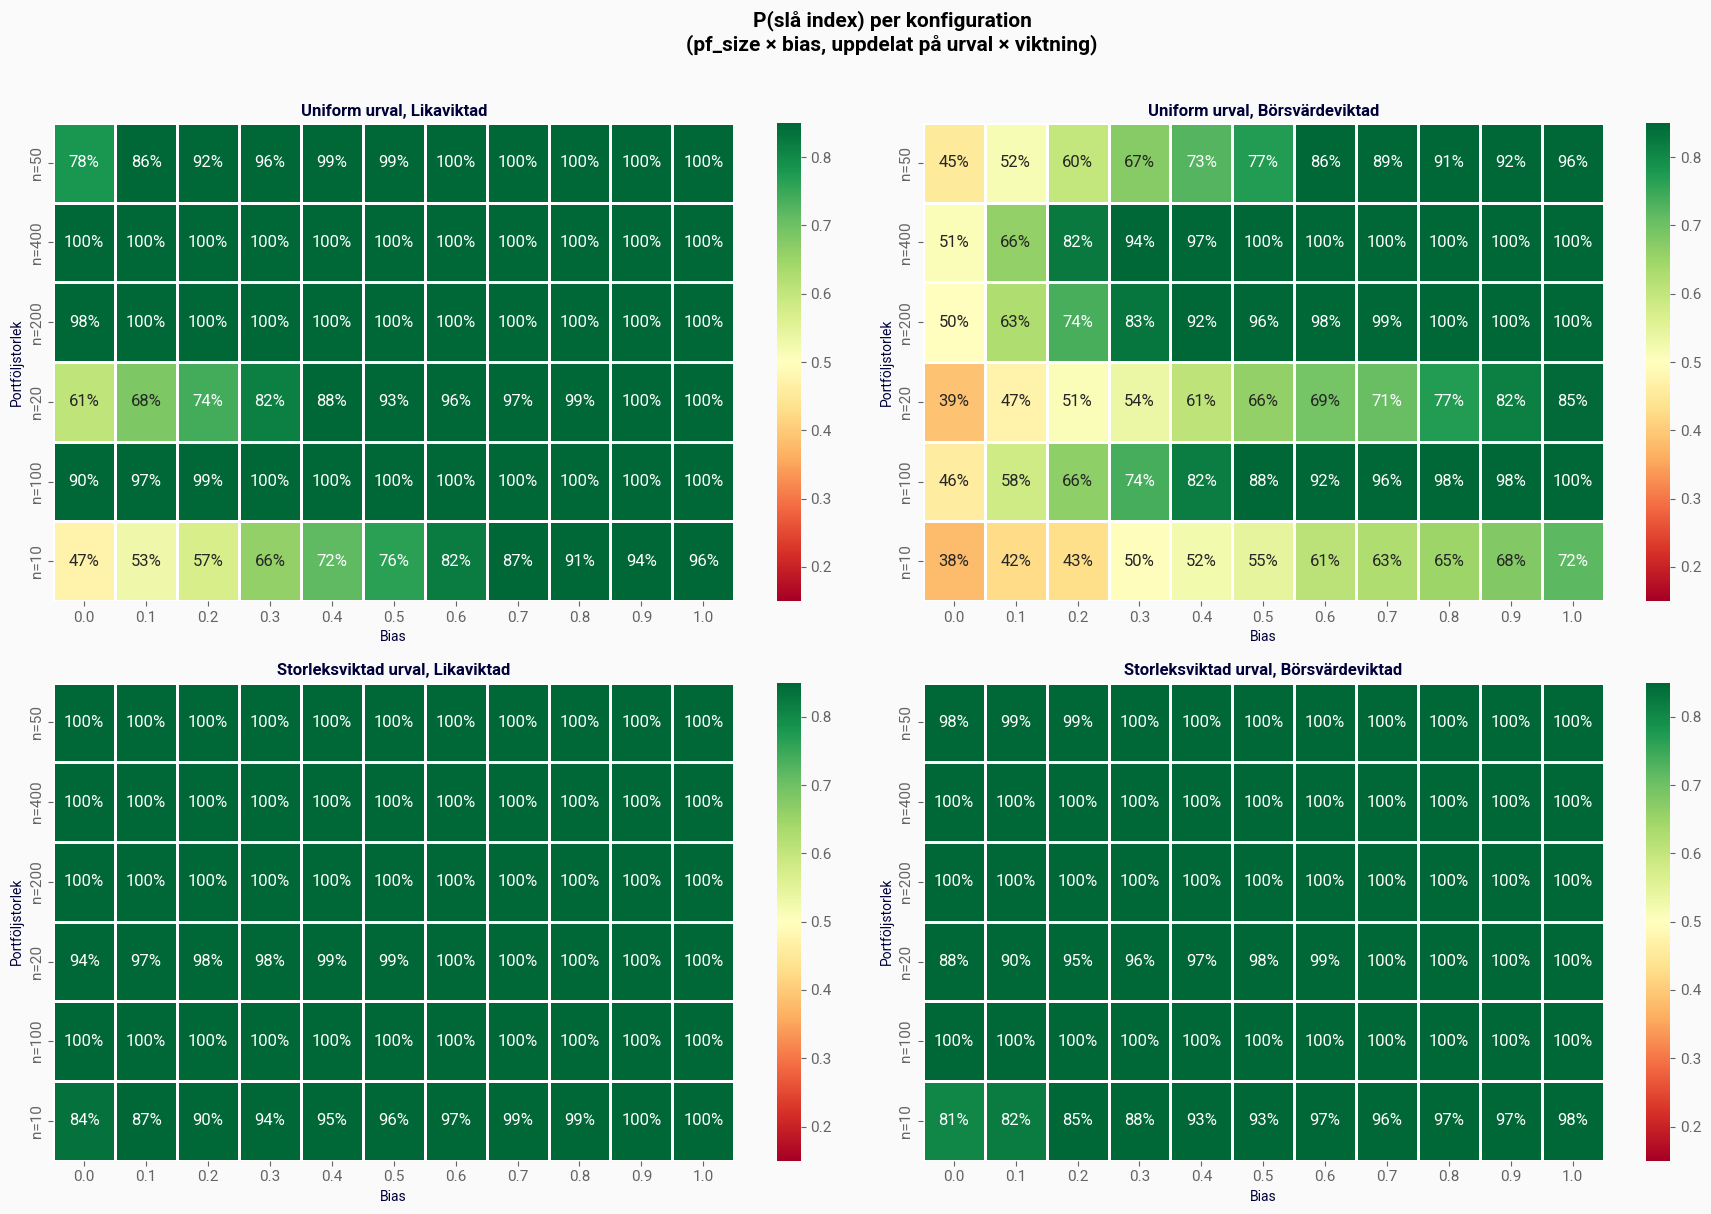

In [29]:
# === Sammanställning: 4-panel P(slå index) ===
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

configs = [
    (0.0, 0.0, "Uniform urval, Likaviktad"),
    (0.0, 1.0, "Uniform urval, Börsvärdeviktad"),
    (1.0, 0.0, "Storleksviktad urval, Likaviktad"),
    (1.0, 1.0, "Storleksviktad urval, Börsvärdeviktad"),
]

for ax, (prob, wt, title) in zip(axes.flat, configs):
    grid = {}
    for b in bias_levels:
        col = []
        for pf_s in pf_sizes_u:
            try:
                v = result["Return"].loc[pd.IndexSlice[pf_s, b, prob, wt]].values.flatten()
                col.append(float(np.mean(v > index_kfs["Return"])))
            except KeyError:
                col.append(np.nan)
        grid[f"{b:.1f}"] = col
    df = pd.DataFrame(grid, index=[f"n={int(s)}" for s in pf_sizes_u])
    sns.heatmap(
        df.sort_index(ascending=False),
        annot=True, fmt=".0%", cmap="RdYlGn", center=0.5,
        linewidths=1, ax=ax, vmin=0.15, vmax=0.85
    )
    ax.grid(False)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Bias", fontsize=10)
    ax.set_ylabel("Portföljstorlek", fontsize=10)

fig.suptitle("P(slå index) per konfiguration\n(pf_size × bias, uppdelat på urval × viktning)",
             fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

In [30]:
# === SLUTLIG SAMMANFATTNING ===
print("=" * 80)
print("SAMMANFATTNING: Sannolikhet att slå index vid rent slumpmässigt urval (bias=0)")
print("=" * 80)

summary_rows = []
for prob, prob_label in [(0.0, "Uniform"), (1.0, "Storleksviktad")]:
    for wt, wt_label in [(0.0, "Likaviktad"), (1.0, "Börsvärdeviktad")]:
        key = f"{prob_label} urval, {wt_label}"
        vals = []
        for pf_s in pf_sizes_u:
            try:
                v = result["Return"].loc[pd.IndexSlice[pf_s, 0.0, prob, wt]].values.flatten()
                vals.append(float(np.mean(v > index_kfs["Return"])))
            except KeyError:
                vals.append(np.nan)
        summary_rows.append((key, vals))

summary_df = pd.DataFrame(
    {k: v for k, v in summary_rows},
    index=[f"n={int(s)}" for s in pf_sizes_u]
)
display(
    summary_df.style
    .format("{:.1%}")
    .background_gradient(cmap="RdYlGn", vmin=0.2, vmax=0.7)
    .set_caption("P(slå index) vid helt slumpmässig stockpicking (bias=0)")
)

print(f"\nIndex årlig avkastning: {index_kfs['Return']:.2%}")
print(f"Index Information Ratio: {index_kfs['Information Ratio']:.2f}")
print(f"Antal aktier i universum: {len(UNIVERSE)}")
print(f"Antal simuleringar per konfiguration: 1 000")

SAMMANFATTNING: Sannolikhet att slå index vid rent slumpmässigt urval (bias=0)


,"Uniform urval, Likaviktad","Uniform urval, Börsvärdeviktad","Storleksviktad urval, Likaviktad","Storleksviktad urval, Börsvärdeviktad"
n=10,47.4%,37.9%,83.6%,80.6%
n=20,60.7%,38.9%,94.2%,88.2%
n=50,78.0%,45.1%,99.6%,98.5%
n=100,89.8%,46.0%,100.0%,100.0%
n=200,98.3%,49.8%,100.0%,100.0%
n=400,100.0%,50.8%,100.0%,100.0%



Index årlig avkastning: 9.15%
Index Information Ratio: 0.54
Antal aktier i universum: 1253
Antal simuleringar per konfiguration: 1 000


---
# 7. Slutsatser

Universum: **1 253 nordiska småbolag**, 1 000 simuleringar per konfiguration (624 kombinationer), indexavkastning **9,15 % p.a.** (IR = 0,54).

## RQ1: Skevhet
- Kraftig positiv skevhet (11,7). **85,6 %** av aktierna underpresterar index; **40,4 %** ger negativ totalavkastning.
- Skevheten förstärks med längre horisont (compound-effekt).

## RQ2: Koncentration
- Gini = **0,77**. Topp 1 % (12 aktier) → **35,8 %** av nettovärdeskapandet; topp 10 % → **83,2 %**.
- Resultaten verkar vara i linje med Bessembinder.

## RQ3: Portföljkonstruktion

**Storlek (a):** P(slå index) vid bias = 0: likaviktad från **47 %** (n = 10) till **100 %** (n = 400). Börsvärdeviktad: **38 %** → **51 %** — diversifiering hjälper knappt.

**Bias (b):** Förbättrar utfallen monotont. Förklarar 28,7 % av avkastningsvariansen och 18,4 % av P(beat)-variansen.

**Viktning (c):** Viktigaste parametern för avkastning — α förklarar **50 %** av variansen (R²), vs bias 29 %, pf_size 2 %. Interaktionen pf_size × α: **53 %**. För P(beat) dominerar istället prob_exp (24 %) och bias (18 %).

**Nyttofunktion (d):** Med $U = \mu - \sigma^2 + \gamma \cdot S$ (börsvärdeviktad) skiftar optimal konfiguration:
- $\gamma = 0$: n = 400, bias = 1,0
- $\gamma = 0,05$: n = 100, bias = 1,0
- $\gamma = 0,10$: n = 20, bias = 1,0
- $\gamma = 0,15$: n = 10, bias = 0,9

## Implikationer
1. **Stockpicking har en strukturell nackdel** — 85,6 % av aktier underpresterar index oavsett förvaltarskicklighet.
2. **Likaviktning är viktigaste konstruktionsparametern** för avkastning (R² = 50 %).
3. **Börsvärdeviktning neutraliserar diversifiering** — n = 400 ger bara ~51 % P(beat).
4. **Skevhetspreferens** motiverar rationellt koncentrerade portföljer, men till priset av lägre P(beat).